## STEP 1  NumPy Warm-Up

In [2]:
import numpy as np
import pandas as pd

np.random.seed(42)

### (a) 6×4 random matrix (0–100)

In [3]:
scores = np.random.randint(0, 101, (6, 4))
print("Original Scores Matrix:\n", scores)

Original Scores Matrix:
 [[51 92 14 71]
 [60 20 82 86]
 [74 74 87 99]
 [23  2 21 52]
 [ 1 87 29 37]
 [ 1 63 59 20]]


### (b) Min-Max normalization (broadcasting only)

In [4]:
col_min = scores.min(axis=0)
col_max = scores.max(axis=0)

normalized = (scores - col_min) / (col_max - col_min)
print("\nNormalized Matrix [0,1]:\n", normalized)


Normalized Matrix [0,1]:
 [[0.68493151 1.         0.         0.64556962]
 [0.80821918 0.2        0.93150685 0.83544304]
 [1.         0.8        1.         1.        ]
 [0.30136986 0.         0.09589041 0.40506329]
 [0.         0.94444444 0.20547945 0.21518987]
 [0.         0.67777778 0.61643836 0.        ]]


### (c) Mask: students avg >= 60

In [5]:
avg_scores = scores.mean(axis=1)
mask = avg_scores >= 60

print("\nAverages:", avg_scores)
print("Passing Mask:", mask)
print("Passing Students:\n", scores[mask])


Averages: [57.   62.   83.5  24.5  38.5  35.75]
Passing Mask: [False  True  True False False False]
Passing Students:
 [[60 20 82 86]
 [74 74 87 99]]


### (d) Replace <40 with column mean

In [6]:
col_mean = scores.mean(axis=0)
replaced = np.where(scores < 40, col_mean, scores)

print("\nScores after replacing <40:\n", replaced)


Scores after replacing <40:
 [[51.         92.         48.66666667 71.        ]
 [60.         56.33333333 82.         86.        ]
 [74.         74.         87.         99.        ]
 [35.         56.33333333 48.66666667 52.        ]
 [35.         87.         48.66666667 60.83333333]
 [35.         63.         59.         60.83333333]]


### (e) Dot product with random weights

In [7]:
weights = np.random.rand(4)
weighted_score = normalized @ weights

print("\nWeights:", weights)
print("Weighted Scores:", weighted_score)


Weights: [0.61748151 0.61165316 0.00706631 0.02306243]
Weighted Scores: [1.0494741  0.64724068 1.13693277 0.19610965 0.58408721 0.41892086]


## STEP 2  Load Dataset & Inspection

In [8]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/yasserh/titanic-dataset/Titanic-Dataset.csv")

In [9]:
print(df.head(10))

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   
5            6         0       3   
6            7         0       1   
7            8         0       3   
8            9         1       3   
9           10         1       2   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   
5                                   Moran, Mr. James    male   NaN      0   
6                            McCarthy, Mr. Timothy J    male  54

In [10]:
print(df.tail(5))

     PassengerId  Survived  Pclass                                      Name  \
886          887         0       2                     Montvila, Rev. Juozas   
887          888         1       1              Graham, Miss. Margaret Edith   
888          889         0       3  Johnston, Miss. Catherine Helen "Carrie"   
889          890         1       1                     Behr, Mr. Karl Howell   
890          891         0       3                       Dooley, Mr. Patrick   

        Sex   Age  SibSp  Parch      Ticket   Fare Cabin Embarked  
886    male  27.0      0      0      211536  13.00   NaN        S  
887  female  19.0      0      0      112053  30.00   B42        S  
888  female   NaN      1      2  W./C. 6607  23.45   NaN        S  
889    male  26.0      0      0      111369  30.00  C148        C  
890    male  32.0      0      0      370376   7.75   NaN        Q  


In [11]:
print(df.sample(8, random_state=42))

     PassengerId  Survived  Pclass  \
709          710         1       3   
439          440         0       2   
840          841         0       3   
720          721         1       2   
39            40         1       3   
290          291         1       1   
300          301         1       3   
333          334         0       3   

                                                  Name     Sex   Age  SibSp  \
709  Moubarek, Master. Halim Gonios ("William George")    male   NaN      1   
439             Kvillner, Mr. Johan Henrik Johannesson    male  31.0      0   
840                        Alhomaki, Mr. Ilmari Rudolf    male  20.0      0   
720                  Harper, Miss. Annie Jessie "Nina"  female   6.0      0   
39                         Nicola-Yarred, Miss. Jamila  female  14.0      1   
290                       Barber, Miss. Ellen "Nellie"  female  26.0      0   
300           Kelly, Miss. Anna Katherine "Annie Kate"  female   NaN      0   
333                    Va

In [12]:
print("Shape:", df.shape)
print(df.info())

Shape: (891, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


In [13]:
print("Columns:", df.columns.tolist())

Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [14]:
num_cat = df.select_dtypes(include='object').shape[1]
num_num = df.select_dtypes(include=['int64','float64']).shape[1]

missing_cols = df.isnull().any().sum()
total_missing = df.isnull().sum().sum()

print("Categorical columns:", num_cat)
print("Numerical columns:", num_num)
print("Columns with missing values:", missing_cols)
print("Total missing values:", total_missing)

Categorical columns: 5
Numerical columns: 7
Columns with missing values: 3
Total missing values: 866


## STEP 3 Missing Value Analysis

In [15]:
import missingno as msno
import matplotlib.pyplot as plt

print(df.isnull().sum())
print((df.isnull().sum()/len(df))*100)

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64


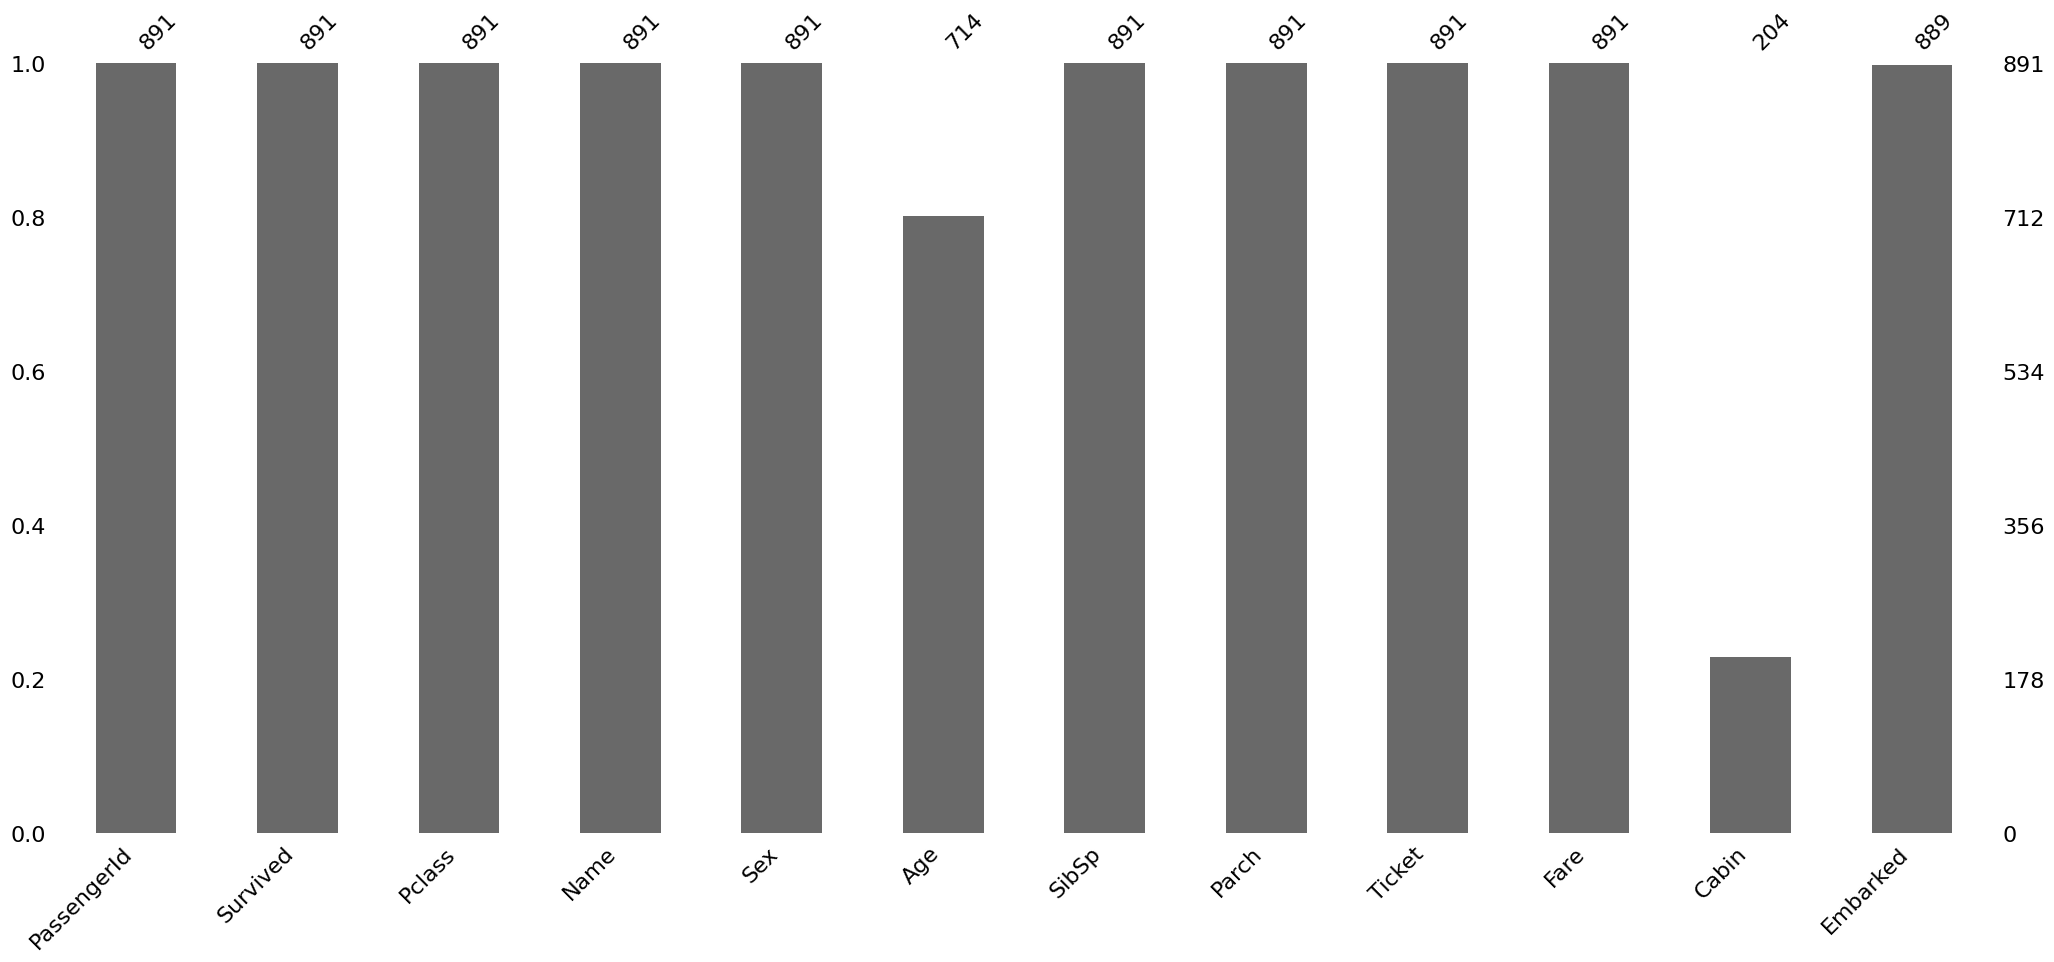

In [16]:
msno.bar(df)

plt.savefig("missing_values.png", dpi=300, bbox_inches='tight')  # save as PNG
plt.show()

In [17]:
top3_missing = df.isnull().sum().sort_values(ascending=False).head(3)
print(top3_missing)

Cabin       687
Age         177
Embarked      2
dtype: int64


## STEP 4 Data Type Fix

In [18]:
print(df.dtypes)

df['Survived'] = df['Survived'].astype('category')
df['Pclass'] = df['Pclass'].astype('category')

before = df.dtypes.copy()

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


## STEP 5  Missing Value Handling

In [19]:
df['Age'] = df.groupby(['Pclass','Sex'])['Age'].transform(lambda x: x.fillna(x.median()))
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

df['has_cabin'] = df['Cabin'].notna().astype(int)
df.drop(columns=['Cabin'], inplace=True)

print(df.isnull().sum().sum())

0


/tmp/ipykernel_57/3944715521.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df['Age'] = df.groupby(['Pclass','Sex'])['Age'].transform(lambda x: x.fillna(x.median()))


## STEP 6  Outliers

In [20]:
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1

upper = Q3 + 1.5*IQR
lower = Q1 - 1.5*IQR

outliers = df[(df['Fare'] > upper) | (df['Fare'] < lower)].shape[0]
print("Fare outliers:", outliers)

df['Fare'] = np.where(df['Fare'] > df['Fare'].quantile(0.99),
                      df['Fare'].quantile(0.99),
                      df['Fare'])

Fare outliers: 116


## STEP 7 Feature Engineering

In [21]:
df['family_size'] = df['SibSp'] + df['Parch'] + 1
df['is_alone'] = (df['family_size'] == 1).astype(int)
df['fare_per_person'] = df['Fare'] / df['family_size']

df['title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
df['title'] = df['title'].replace(['Mlle','Ms','Mme'], 'Rare')

df['age_group'] = pd.cut(df['Age'],
                         bins=[0,12,18,60,100],
                         labels=['Child','Teen','Adult','Senior'])

df['fare_bin'] = pd.qcut(df['Fare'], 4, labels=['Low','Medium','High','VHigh'])

print(df[['family_size','is_alone','fare_per_person','title','age_group','fare_bin']].head())

   family_size  is_alone  fare_per_person title age_group fare_bin
0            2         0          3.62500    Mr     Adult      Low
1            2         0         35.64165   Mrs     Adult    VHigh
2            1         1          7.92500  Miss     Adult   Medium
3            2         0         26.55000   Mrs     Adult    VHigh
4            1         1          8.05000    Mr     Adult   Medium


<>:5: SyntaxWarning: invalid escape sequence '\.'
<>:5: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_57/2230115347.py:5: SyntaxWarning: invalid escape sequence '\.'
  df['title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


## STEP 8 Encoding

In [22]:
df['sex_encoded'] = df['Sex'].map({'male':0,'female':1})

df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)
df = pd.get_dummies(df, columns=['title'], drop_first=True)

age_map = {'Child':0,'Teen':1,'Adult':2,'Senior':3}
df['age_group'] = df['age_group'].map(age_map)

fare_map = {'Low':0,'Medium':1,'High':2,'VHigh':3}
df['fare_bin'] = df['fare_bin'].map(fare_map)

print(df.shape)

(891, 33)


## STEP 9 Scaling

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

cols = ['Age','Fare','fare_per_person','family_size']
df[cols] = scaler.fit_transform(df[cols])

print(df[cols].mean())
print(df[cols].std())

Age                2.153160e-16
Fare              -5.582266e-17
fare_per_person    1.993666e-17
family_size       -2.392400e-17
dtype: float64
Age                1.000562
Fare               1.000562
fare_per_person    1.000562
family_size        1.000562
dtype: float64


## STEP 10 Survival Analysis

In [24]:
df['Survived'] = df['Survived'].astype(int)

print(df.groupby('Pclass')['Survived'].mean())
print(df.groupby('Sex')['Survived'].mean())
print(df.groupby(['Pclass','Sex'])['Survived'].mean().unstack())
print(df.groupby('age_group')['Survived'].mean())
print(df.groupby('is_alone')['Survived'].mean())

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64
Sex       female      male
Pclass                    
1       0.968085  0.368852
2       0.921053  0.157407
3       0.500000  0.135447
age_group
0    0.579710
1    0.428571
2    0.365753
3    0.227273
Name: Survived, dtype: float64
is_alone
0    0.505650
1    0.303538
Name: Survived, dtype: float64


/tmp/ipykernel_57/3286454379.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('Pclass')['Survived'].mean())
/tmp/ipykernel_57/3286454379.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby(['Pclass','Sex'])['Survived'].mean().unstack())
/tmp/ipykernel_57/3286454379.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('age_group')['Survived'].mean())


## STEP 11 Aggregation

In [25]:
df.groupby('Pclass')['Fare'].agg(['mean','median','std','min','max'])

df.groupby('Pclass').agg({'Survived':'mean'})

/tmp/ipykernel_57/2083891800.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Pclass')['Fare'].agg(['mean','median','std','min','max'])
/tmp/ipykernel_57/2083891800.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Pclass').agg({'Survived':'mean'})


,Survived
Pclass,
1,0.629630
2,0.472826
3,0.242363


## STEP 12 Pivot Table

In [26]:
pivot = pd.pivot_table(df, values='Survived',
                       index='Pclass',
                       columns='Sex',
                       aggfunc='mean')

print(pivot)

Sex       female      male
Pclass                    
1       0.968085  0.368852
2       0.921053  0.157407
3       0.500000  0.135447


/tmp/ipykernel_57/2655826748.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = pd.pivot_table(df, values='Survived',


## STEP 13 Correlation

In [27]:
corr = df.corr(numeric_only=True)
print(corr['Survived'].sort_values(ascending=False))

Survived           1.000000
sex_encoded        0.543351
title_Mrs          0.339040
title_Miss         0.327093
has_cabin          0.316912
Fare               0.273008
fare_per_person    0.246441
title_Master       0.085221
title_Rare         0.085083
Parch              0.081629
title_Lady         0.042470
title_Sir          0.042470
title_Countess     0.042470
family_size        0.016639
title_Major        0.011329
title_Col          0.011329
title_Dr           0.008185
Embarked_Q         0.003650
PassengerId       -0.005007
title_Don         -0.026456
title_Jonkheer    -0.026456
SibSp             -0.035322
Age               -0.059579
title_Rev         -0.064988
Embarked_S        -0.149683
is_alone          -0.203367
title_Mr          -0.549199
Name: Survived, dtype: float64


## STEP 14 NumPy Analysis

In [28]:
arr = df.select_dtypes(include=np.number).values

print(np.mean(arr, axis=0))
print(np.std(arr, axis=0))

z = (arr - arr.mean(axis=0)) / arr.std(axis=0)
print(z.mean(axis=0))

surv = df[df['Survived']==1]
dead = df[df['Survived']==0]

print("Survivors Fare:", surv['Fare'].mean())
print("Non-Survivors Fare:", dead['Fare'].mean())

[ 4.46000000e+02  3.83838384e-01  2.15315981e-16  5.23007856e-01
  3.81593715e-01 -5.58226616e-17  2.28956229e-01 -2.39239978e-17
  6.02693603e-01  1.99366649e-17  3.52413019e-01]
[257.20938293   0.48631932   1.           1.10212444   0.80560476
   1.           0.42016101   1.           0.4893404    1.
   0.47772176]
[ 6.37973276e-17  3.98733297e-17  1.19619989e-17  4.38606627e-17
  5.38289951e-17  5.98099946e-18 -7.37656600e-17 -9.17086584e-17
 -6.37973276e-17  1.19619989e-17  3.98733297e-17]
Survivors Fare: 0.3458985036383721
Non-Survivors Fare: -0.21547775636488764


## STEP 15 Dashboard (6 Charts)

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# rebuild title
df['title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
df['title'] = df['title'].replace([
    'Mlle','Ms','Mme','Lady','Countess','Capt','Col','Don','Dr','Major',
    'Rev','Sir','Jonkheer','Dona'
], 'Rare')

<>:5: SyntaxWarning: invalid escape sequence '\.'
<>:5: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_57/2087226111.py:5: SyntaxWarning: invalid escape sequence '\.'
  df['title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


### Survival by Pclass

/tmp/ipykernel_57/95654148.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Pclass')['Survived'].mean().plot(kind='bar')


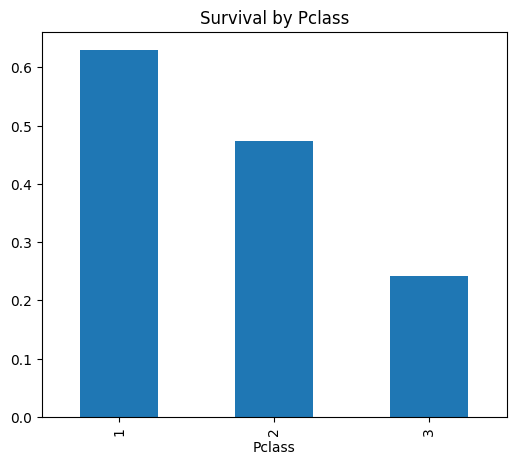

In [30]:
plt.figure(figsize=(6,5))
df.groupby('Pclass')['Survived'].mean().plot(kind='bar')
plt.title("Survival by Pclass")
plt.savefig("chart1_survival_pclass.png", dpi=300, bbox_inches='tight')
plt.show()


###  Age vs Survived

<Figure size 600x500 with 0 Axes>

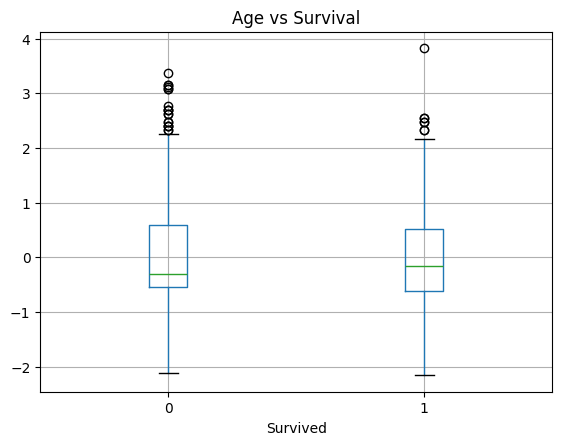

In [31]:
plt.figure(figsize=(6,5))
df.boxplot(column='Age', by='Survived')
plt.title("Age vs Survival")
plt.suptitle("")  # remove default title
plt.savefig("chart2_age_survival.png", dpi=300, bbox_inches='tight')
plt.show()

###  Fare vs Pclass

<Figure size 600x500 with 0 Axes>

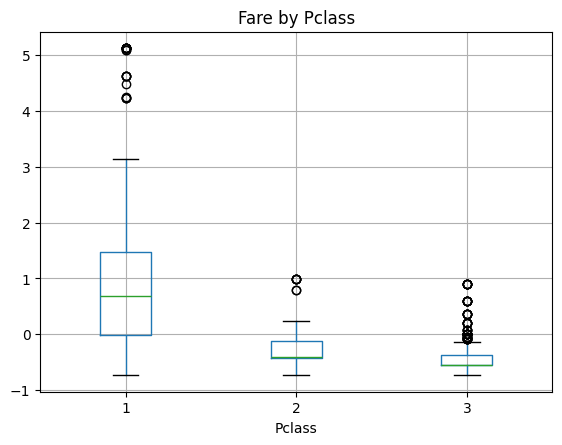

In [32]:
plt.figure(figsize=(6,5))
df.boxplot(column='Fare', by='Pclass')
plt.title("Fare by Pclass")
plt.suptitle("")
plt.savefig("chart3_fare_pclass.png", dpi=300, bbox_inches='tight')
plt.show()

###  Heatmap

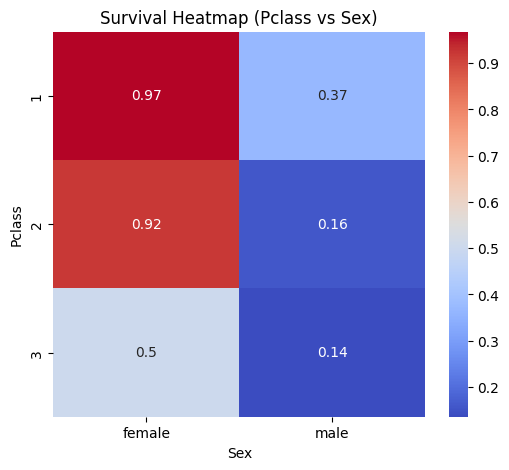

In [33]:
plt.figure(figsize=(6,5))
sns.heatmap(pivot, annot=True, cmap='coolwarm')
plt.title("Survival Heatmap (Pclass vs Sex)")
plt.savefig("chart4_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

### Family Size vs Survival

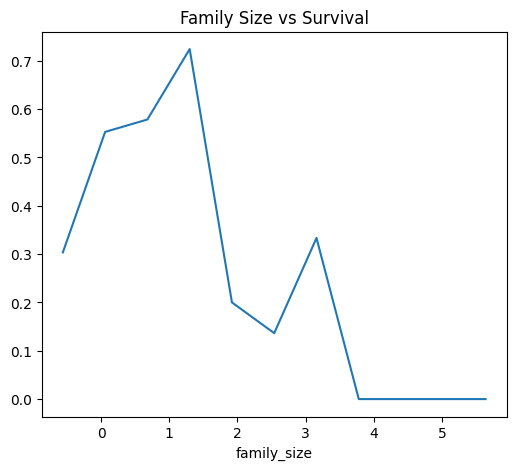

In [34]:
plt.figure(figsize=(6,5))
df.groupby('family_size')['Survived'].mean().plot()
plt.title("Family Size vs Survival")
plt.savefig("chart5_family_survival.png", dpi=300, bbox_inches='tight')
plt.show()

### Title vs Survival

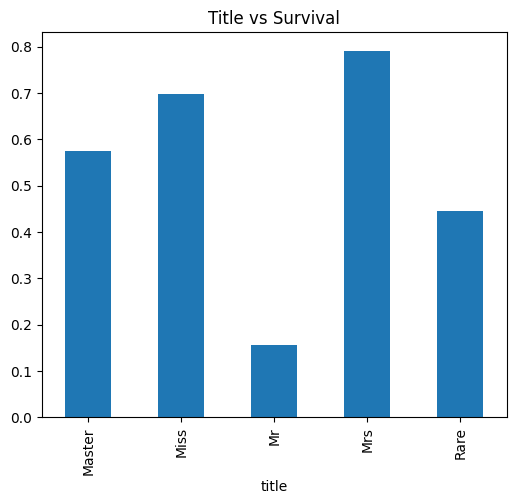

In [35]:
plt.figure(figsize=(6,5))
df.groupby('title')['Survived'].mean().plot(kind='bar')
plt.title("Title vs Survival")
plt.savefig("chart6_title_survival.png", dpi=300, bbox_inches='tight')
plt.show()

## 1. Executive Summary

This project analyzes the Titanic dataset containing 891 passengers to understand the factors influencing survival. The main objective was to clean the dataset, engineer meaningful features, and extract insights useful for machine learning models. After preprocessing and analysis, several strong predictors of survival were identified. Gender (Sex) emerged as the most influential factor, with females having a survival rate of 74.2%, compared to only 18.9% for males. Passenger class also played a major role, with first-class passengers having a survival rate of 62.9%, while third-class passengers had only 24.2%. Additionally, passengers traveling with family had higher survival chances compared to those traveling alone. These findings demonstrate that social status, gender, and family structure significantly influenced survival outcomes.

## 2. Data Quality Assessment

The dataset initially contained 12 columns and 891 rows, with 866 missing values across three columns: Age, Cabin, and Embarked. The ‘Cabin’ column had the highest missing rate (77.1%), making it unreliable for direct use. ‘Age’ had 19.86% missing values, which is significant but still recoverable using imputation. ‘Embarked’ had only 2 missing values, which is negligible. Data types were mostly correct, though categorical features like Sex and Embarked required encoding. To handle missing data, group-based median imputation was applied to Age, mode imputation to Embarked, and Cabin was transformed into a binary feature (‘has_cabin’) before being dropped. These strategies preserved important information while ensuring no missing values remained.

## 3. Feature Engineering Rationale

Several new features were created to enhance model performance. The ‘family_size’ feature was derived from SibSp and Parch to represent total family members onboard, and ‘is_alone’ was created to identify passengers traveling alone. ‘fare_per_person’ provided a normalized measure of ticket cost per individual. The ‘title’ feature, extracted from passenger names, captured social status and indirectly represented gender and age groups. ‘age_group’ categorized passengers into Child, Teen, Adult, and Senior, making patterns easier to analyze. ‘fare_bin’ grouped fares into quartiles to reduce skewness. These engineered features added meaningful context and improved the dataset’s predictive power.

## 4. Key Statistical Findings

The analysis revealed strong survival patterns. Gender was the strongest predictor: females had a survival rate of 0.742, while males had only 0.189. Passenger class also showed a clear trend: Class 1 (0.629), Class 2 (0.473), and Class 3 (0.242). When combined, first-class females had the highest survival rate (0.968), while third-class males had the lowest (0.135). Age group analysis showed that children had the highest survival rate (0.579), while seniors had the lowest (0.227). Passengers traveling with family had a higher survival rate (0.505) compared to those traveling alone (0.303). These results confirm that priority evacuation favored women, children, and higher-class passengers.

## 5. Visualization Insights

Visualizations further reinforced these findings. Bar charts showed a clear decline in survival from first to third class. Box plots indicated that higher fares were associated with higher survival, suggesting economic status played a role. The heatmap of Pclass vs Sex highlighted extreme differences, especially the very high survival rate of first-class females. The family size plot revealed that moderate family sizes improved survival chances, while being alone reduced them. The title-based chart showed that categories like “Mrs” and “Miss” had higher survival rates compared to “Mr.” Overall, visualizations made it clear that survival was not random but strongly influenced by social hierarchy and demographics.

## 6. Feature Selection Recommendation

Based on correlation analysis and statistical importance, the following features are recommended for a machine learning model:

sex_encoded (0.543 correlation)
Pclass
Fare (0.273)
fare_per_person (0.246)
has_cabin (0.316)
title (especially Mr, Mrs, Miss)
is_alone (-0.203)

These features capture gender, economic status, social class, and family structure, which are the most influential survival factors. Using these features in models like Logistic Regression or Random Forest is expected to produce strong predictive performance.

## 7. Reflection

The most challenging part of this project was feature engineering and encoding categorical variables correctly. Extracting meaningful information from text data (like the ‘title’ feature) required careful processing. Another challenge was handling missing values without losing important information, especially for the Age column. One surprising insight was how strongly gender influenced survival, even more than fare or age. If given more time, I would experiment with advanced models and feature selection techniques to further improve accuracy. Overall, this project provided valuable hands-on experience in real-world data preprocessing and analysis.